In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
data =pd.read_excel("C:\\Users\\G.B\\Desktop\\المرحلة الاولى\\data science and machine learning\\dataset\\startup-expansion.xlsx")

data.head()

,Store ID,City,State,Sales Region,New Expansion,Marketing Spend,Revenue
0,1,Peoria,Arizona,Region 2,Old,2601.0,48610
1,2,Midland,Texas,Region 2,Old,2727.0,45689
2,3,Spokane,Washington,NaN,Old,2768.0,49554
3,4,Denton,Texas,Region 2,Old,NaN,38284
4,5,Overland Park,Kansas,Region 2,Old,2869.0,59887


In [21]:
# mean , median , most_frequent , constant   
data['Sales Region']=data['Sales Region'].fillna(data['Sales Region'].most_frequent())
data.head()

AttributeError: 'Series' object has no attribute 'most_frequent'

In [18]:
from sklearn import preprocessing

lb=preprocessing.LabelEncoder()

obj_data=data.select_dtypes(include=["object"])
#print(obj_data)
num_data=data.select_dtypes(exclude=["object"])

for i in range(0,obj_data.shape[1]):
    obj_data.iloc[:,i]=lb.fit_transform(obj_data.iloc[:,i])

data = pd.concat([obj_data,num_data],axis=1)
print(data)

     City  State  Sales Region  New Expansion  Store ID  Marketing Spend  \
0      94      1             1              1         1           2601.0   
1      71     30             1              1         2           2727.0   
2     121     33             2              1         3           2768.0   
3      31     30             1              1         4              NaN   
4      88     11             1              1         5           2869.0   
..    ...    ...           ...            ...       ...              ...   
145    92     19             0              0       146           2251.0   
146    11     30             1              0       147           3675.0   
147   105      8             0              0       148           2648.0   
148    21     30             1              0       149           2994.0   
149   131      3             1              0       150           2431.0   

     Revenue  
0      48610  
1      45689  
2      49554  
3      38284  
4      59887

In [19]:
from sklearn.impute import SimpleImputer

imputer=SimpleImputer(missing_values=np.nan,strategy="mean")

clear_data=imputer.fit_transform(data)
print("======")
print(clear_data)
new_data=pd.DataFrame(clear_data,columns=data.columns)
print(new_data)
data.head()

[[9.4000e+01 1.0000e+00 1.0000e+00 ... 1.0000e+00 2.6010e+03 4.8610e+04]
 [7.1000e+01 3.0000e+01 1.0000e+00 ... 2.0000e+00 2.7270e+03 4.5689e+04]
 [1.2100e+02 3.3000e+01 2.0000e+00 ... 3.0000e+00 2.7680e+03 4.9554e+04]
 ...
 [1.0500e+02 8.0000e+00 0.0000e+00 ... 1.4800e+02 2.6480e+03 4.3377e+04]
 [2.1000e+01 3.0000e+01 1.0000e+00 ... 1.4900e+02 2.9940e+03 2.2457e+04]
 [1.3100e+02 3.0000e+00 1.0000e+00 ... 1.5000e+02 2.4310e+03 4.0141e+04]]
      City  State  Sales Region  New Expansion  Store ID  Marketing Spend  \
0     94.0    1.0           1.0            1.0       1.0      2601.000000   
1     71.0   30.0           1.0            1.0       2.0      2727.000000   
2    121.0   33.0           2.0            1.0       3.0      2768.000000   
3     31.0   30.0           1.0            1.0       4.0      2896.081081   
4     88.0   11.0           1.0            1.0       5.0      2869.000000   
..     ...    ...           ...            ...       ...              ...   
145   92.0   19.0

,City,State,Sales Region,New Expansion,Store ID,Marketing Spend,Revenue
0,94,1,1,1,1,2601.0,48610
1,71,30,1,1,2,2727.0,45689
2,121,33,2,1,3,2768.0,49554
3,31,30,1,1,4,NaN,38284
4,88,11,1,1,5,2869.0,59887


In [3]:
data.describe().round(1)

,Store ID,Marketing Spend,Revenue
count,150.0,150.0,150.0
mean,75.5,2893.1,39301.4
std,43.4,367.9,15465.8
min,1.0,1811.0,15562.0
25%,38.2,2662.2,21113.5
50%,75.5,2898.0,42993.0
75%,112.8,3111.5,51145.5
max,150.0,3984.0,68828.0


In [4]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 7 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   Store ID         150 non-null    int64 
 1   City             150 non-null    object
 2   State            150 non-null    object
 3   Sales Region     150 non-null    object
 4   New Expansion    150 non-null    object
 5   Marketing Spend  150 non-null    int64 
 6   Revenue          150 non-null    int64 
dtypes: int64(3), object(4)
memory usage: 8.3+ KB


In [13]:
data['State'].value_counts()

California        40
Texas             17
Florida           12
Washington         7
Colorado           5
Illinois           5
Georgia            4
Alabama            4
Connecticut        4
New Jersey         4
Arizona            3
Tennessee          3
Iowa               3
Michigan           3
South Carolina     3
Utah               3
Massachusetts      3
Kansas             3
New York           3
Louisiana          2
North Carolina     2
Ohio               2
Virginia           2
Oregon             2
Mississippi        1
New Mexico         1
Arkansas           1
New Hampshire      1
Oklahoma           1
Montana            1
Indiana            1
South Dakota       1
Minnesota          1
Wisconsin          1
Rhode Island       1
Name: State, dtype: int64

In [20]:
data.head()

,Store ID,City,State,Sales Region,New Expansion,Marketing Spend,Revenue
0,1,Peoria,Arizona,Region 2,Old,2601,48610
1,2,Midland,Texas,Region 2,Old,2727,45689
2,3,Spokane,Washington,Region 2,Old,2768,49554
3,4,Denton,Texas,Region 2,Old,2759,38284
4,5,Overland Park,Kansas,Region 2,Old,2869,59887


In [6]:
data['State'].unique()

AttributeError: 'DataFrame' object has no attribute 'unique'

In [28]:
data['State'].nunique()

35

In [29]:
data.head()

,Store ID,City,State,Sales Region,New Expansion,Marketing Spend,Revenue
0,1,Peoria,Arizona,Region 2,Old,2601,48610
1,2,Midland,Texas,Region 2,Old,2727,45689
2,3,Spokane,Washington,Region 2,Old,2768,49554
3,4,Denton,Texas,Region 2,Old,2759,38284
4,5,Overland Park,Kansas,Region 2,Old,2869,59887


<AxesSubplot:>

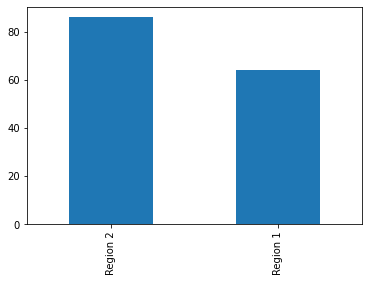

In [33]:
data['Sales Region'].value_counts().plot.bar()

<AxesSubplot:>

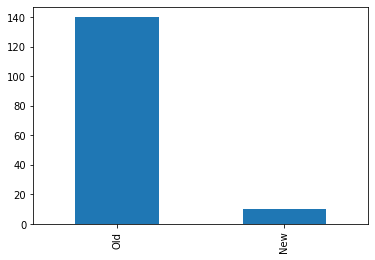

In [34]:
data['New Expansion'].value_counts().plot.bar()

In [35]:
data.head()

,Store ID,City,State,Sales Region,New Expansion,Marketing Spend,Revenue
0,1,Peoria,Arizona,Region 2,Old,2601,48610
1,2,Midland,Texas,Region 2,Old,2727,45689
2,3,Spokane,Washington,Region 2,Old,2768,49554
3,4,Denton,Texas,Region 2,Old,2759,38284
4,5,Overland Park,Kansas,Region 2,Old,2869,59887


                 Store ID  Marketing Spend   Revenue
Store ID         1.000000        -0.059846 -0.013470
Marketing Spend -0.059846         1.000000  0.087806
Revenue         -0.013470         0.087806  1.000000


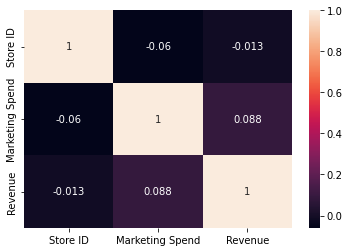

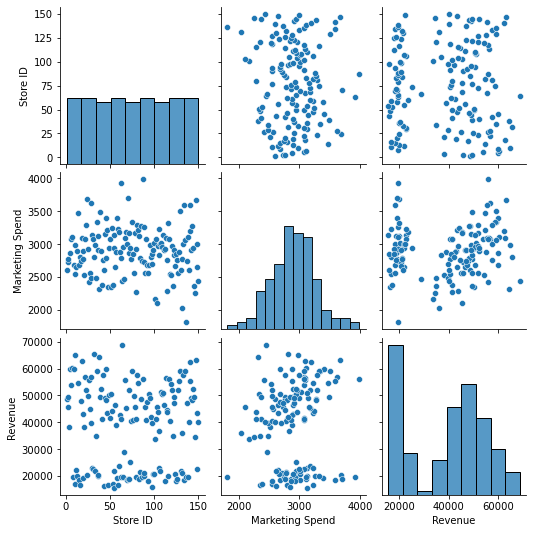

In [6]:
c=data.corr()
print(c)
sns.heatmap(c,annot=True)
sns.pairplot(data)
plt.show()

In [9]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 7 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Store ID         150 non-null    int64  
 1   City             150 non-null    object 
 2   State            150 non-null    object 
 3   Sales Region     149 non-null    object 
 4   New Expansion    150 non-null    object 
 5   Marketing Spend  148 non-null    float64
 6   Revenue          150 non-null    int64  
dtypes: float64(1), int64(2), object(4)
memory usage: 8.3+ KB


In [7]:
data.head()

,Store ID,City,State,Sales Region,New Expansion,Marketing Spend,Revenue
0,1,Peoria,Arizona,Region 2,Old,2601.0,48610
1,2,Midland,Texas,Region 2,Old,2727.0,45689
2,3,Spokane,Washington,NaN,Old,2768.0,49554
3,4,Denton,Texas,Region 2,Old,NaN,38284
4,5,Overland Park,Kansas,Region 2,Old,2869.0,59887


array([[<AxesSubplot:title={'center':'Store ID'}>,
        <AxesSubplot:title={'center':'Marketing Spend'}>],
       [<AxesSubplot:title={'center':'Revenue'}>, <AxesSubplot:>]],
      dtype=object)

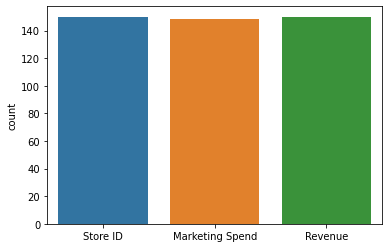

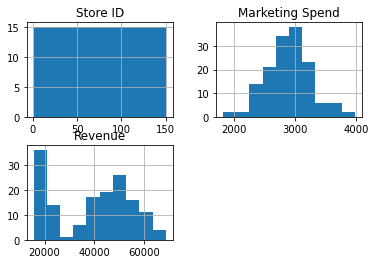